In [10]:
import pandas as pd
import numpy as np
import pickle #Salvar tradutores

# TensorFlow e Keras (tive que seperar para evitar erro)
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional # type: ignore
from tensorflow.keras.models import load_model # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

# Biblioteca do sklearn
from sklearn.preprocessing import LabelEncoder


# Parametros (tive que criar para mexer manualmente, sem ler o codigo completo)
vocab = 5000
maxlen = 20
path_dados = '../data/dataset.csv' #preciso de um dataset centralizado com todas as informações
path_models = '../models/'
epochs = 100
batch_size = 32
unidades_lstm = 128

# Vetorização 
df = pd.read_csv(path_dados)

#pegar os valores direto
perguntas = df['perguntas'].values
respostas = df['respostas'].values

#print de teste
print(f"Encontradas {len(perguntas)} perguntas e {len(respostas)} respostas.")

#todo o processo de desenvolvimento da RNN será uma LSTM com o Keras API
tokenizer = Tokenizer(num_words=vocab, oov_token="<OOV>") #limite de palavras e o oov_token para palavras fora do vocabulario
tokenizer.fit_on_texts(perguntas)
x_perguntas = tokenizer.texts_to_sequences(perguntas) #transforma todas as palavras em sequencias numericas (coluna x)
x_processadas = pad_sequences(x_perguntas, maxlen=maxlen, padding='post')

print("Exemplo de X (bruto):", perguntas[0])
print("Exemplo de X (processado):", x_processadas[0])

#Processo de Codificação Categórica
label_encoder = LabelEncoder()
y_respostas = label_encoder.fit_transform(np.array(respostas)) #transforma as respostas em numeros, aplicado o np.array para evitar erro
y_respostas = np.array(y_respostas)  # Força conversão para NumPy array, apenas para o vscode não reclamar
#aparentemente o LabelEncoder não aceita Series do pandas diretamente

print("Exemplo de Y (bruto):", respostas[0])
print("Exemplo de Y (Label):", y_respostas[0])

#vou converter os IDs para One-Hot Encoding, trabalhar apenas com o metodo binario, isso facilita a vida da rede neural, treinamento e categorização
num_classes = len(np.unique(y_respostas)) #calcular o output unico
y_categorico = to_categorical(y_respostas, num_classes=num_classes)

print(f"Total de classes (respostas únicas): {num_classes}")
print("Exemplo de Y (Categorical/One-Hot):", y_categorico[0])

with open(path_models + 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open(path_models + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)


model = Sequential()

#Embedding transforma os IDs em vetores densos e é aqui que ela ira aprender o "significado" e contexto das palavras
model.add(Embedding(input_dim=vocab, 
                    output_dim=64,
                    input_length=maxlen))

'''
#Primeira camada LSTM
model.add(LSTM(units=unidades_lstm, return_sequences=True))
model.add(Dropout(0.3))

#Segunda camada LSTM
model.add(LSTM(units=unidades_lstm // 2)) #metade das unidades
model.add(Dropout(0.3))

#tentei efetuar o processo em duas camadas, mas o empilhamento bidirecional é mais eficiente
'''
#tentando um moeto de empilhamento bidirecional
model.add(Bidirectional(LSTM(units=unidades_lstm)))
model.add(Dropout(0.2))

#É a saida de decisão, pega os valores de LSTM e decide a resposta a retornar
model.add(Dense(units=num_classes, activation='softmax'))

#Treinar o Modelo
model.compile(loss='categorical_crossentropy', # Função de perda para classificação
              optimizer='adam',                 # Otimizador padrão
              metrics=['accuracy'])             # Queremos ver a acurácia
model.summary() #mostrar arquitetura

'''
fazer o uso do val_loss dentro do monitoramento é mais preciso para a aprendizagem da IA
val_accuracy ou a propia accuracy não é ensinar, apenas decorar as palavras com respostas 
'''
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=20, 
                               restore_best_weights=True)

history = model.fit(x_processadas, 
                    y_categorico, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    validation_split=0.3,
                    callbacks=[early_stopping])

#Salvar o modelo que treinei
model.save('../models/chatbotIA.keras') #antes estava usando o h5, mas era uma forma legada, atualizado para o proprio keras


Encontradas 102 perguntas e 102 respostas.
Exemplo de X (bruto): oi
Exemplo de X (processado): [85  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Exemplo de Y (bruto): Oi! Tudo bem?
Exemplo de Y (Label): 21
Total de classes (respostas únicas): 39
Exemplo de Y (Categorical/One-Hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


/usr/local/python/3.13.9/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 417ms/step - accuracy: 0.1127 - loss: 3.6386 - val_accuracy: 0.0000e+00 - val_loss: 3.6767
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1972 - loss: 3.5077 - val_accuracy: 0.0000e+00 - val_loss: 3.7085
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1972 - loss: 3.1797 - val_accuracy: 0.0000e+00 - val_loss: 3.8551
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1972 - loss: 2.5006 - val_accuracy: 0.0000e+00 - val_loss: 4.7037
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1831 - loss: 2.2594 - val_accuracy: 0.0000e+00 - val_loss: 5.7876
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0986 - loss: 2.0342 - val_accuracy: 0.0000e+00 - val_loss: 6.5306
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.1408 - loss: 2.1006 - val_accuracy: 0.0000e+00 - val_loss: 7.0259
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1127 - loss: 2.0933 - val_accuracy: 0

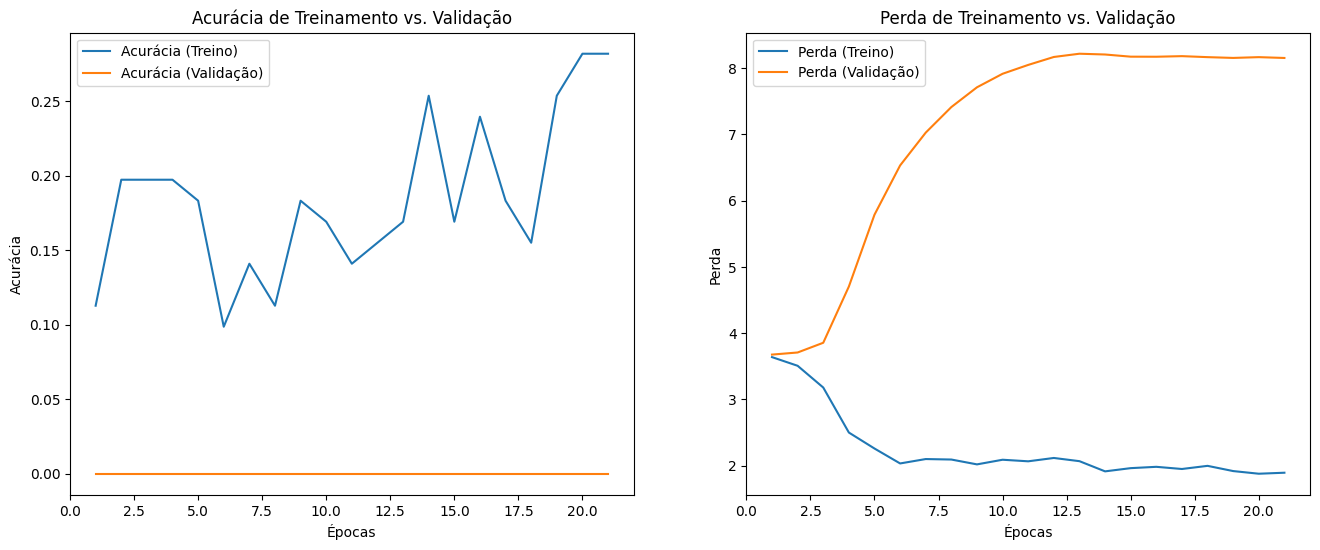

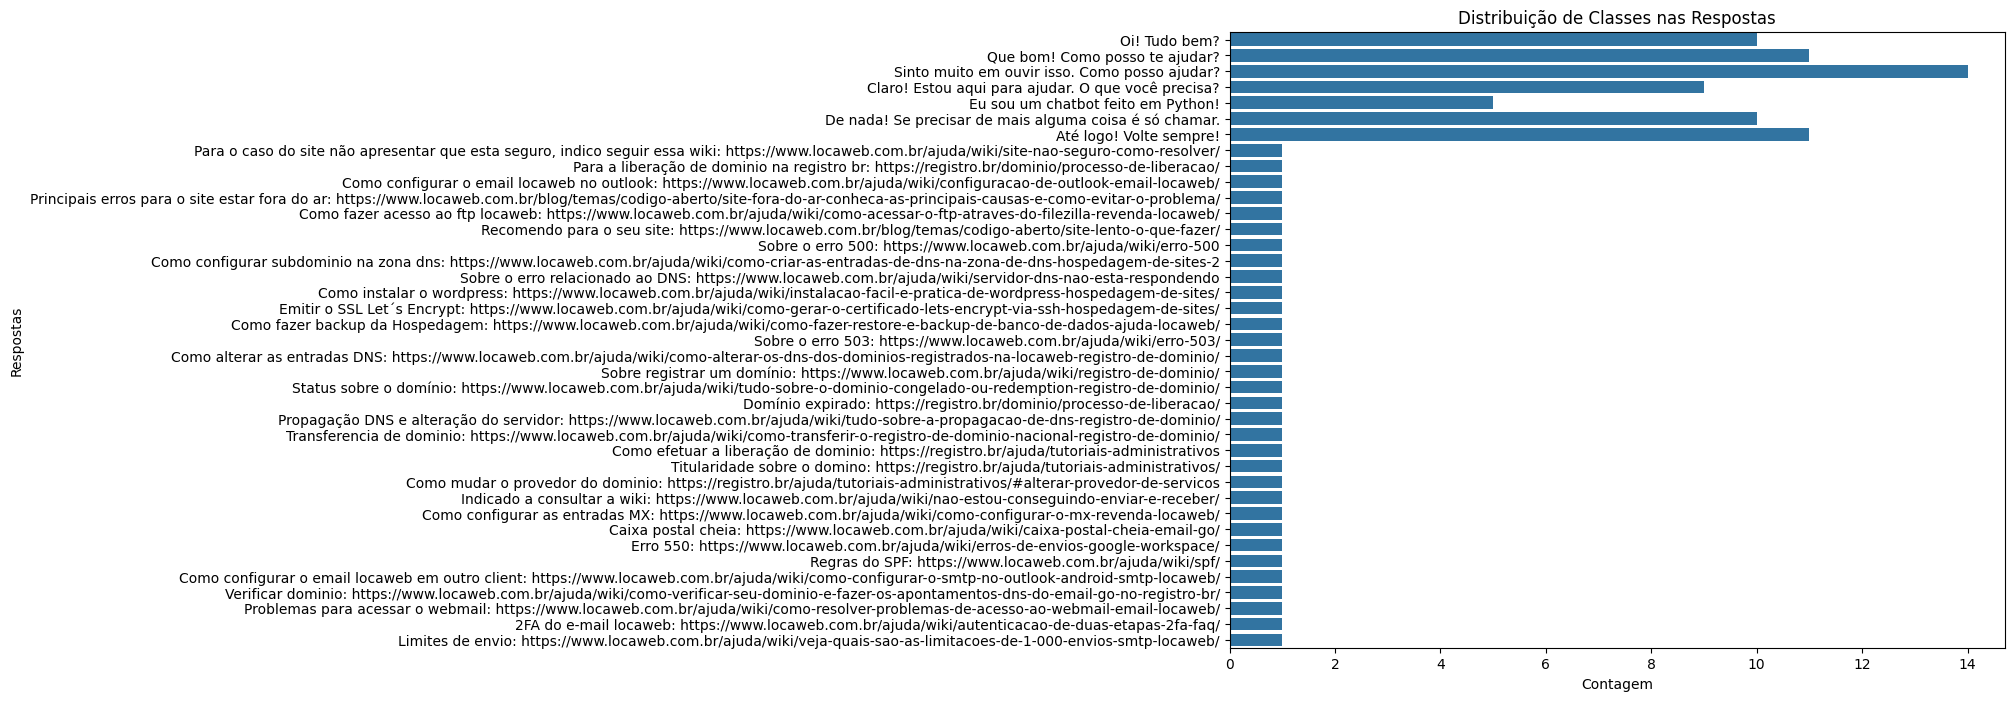

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


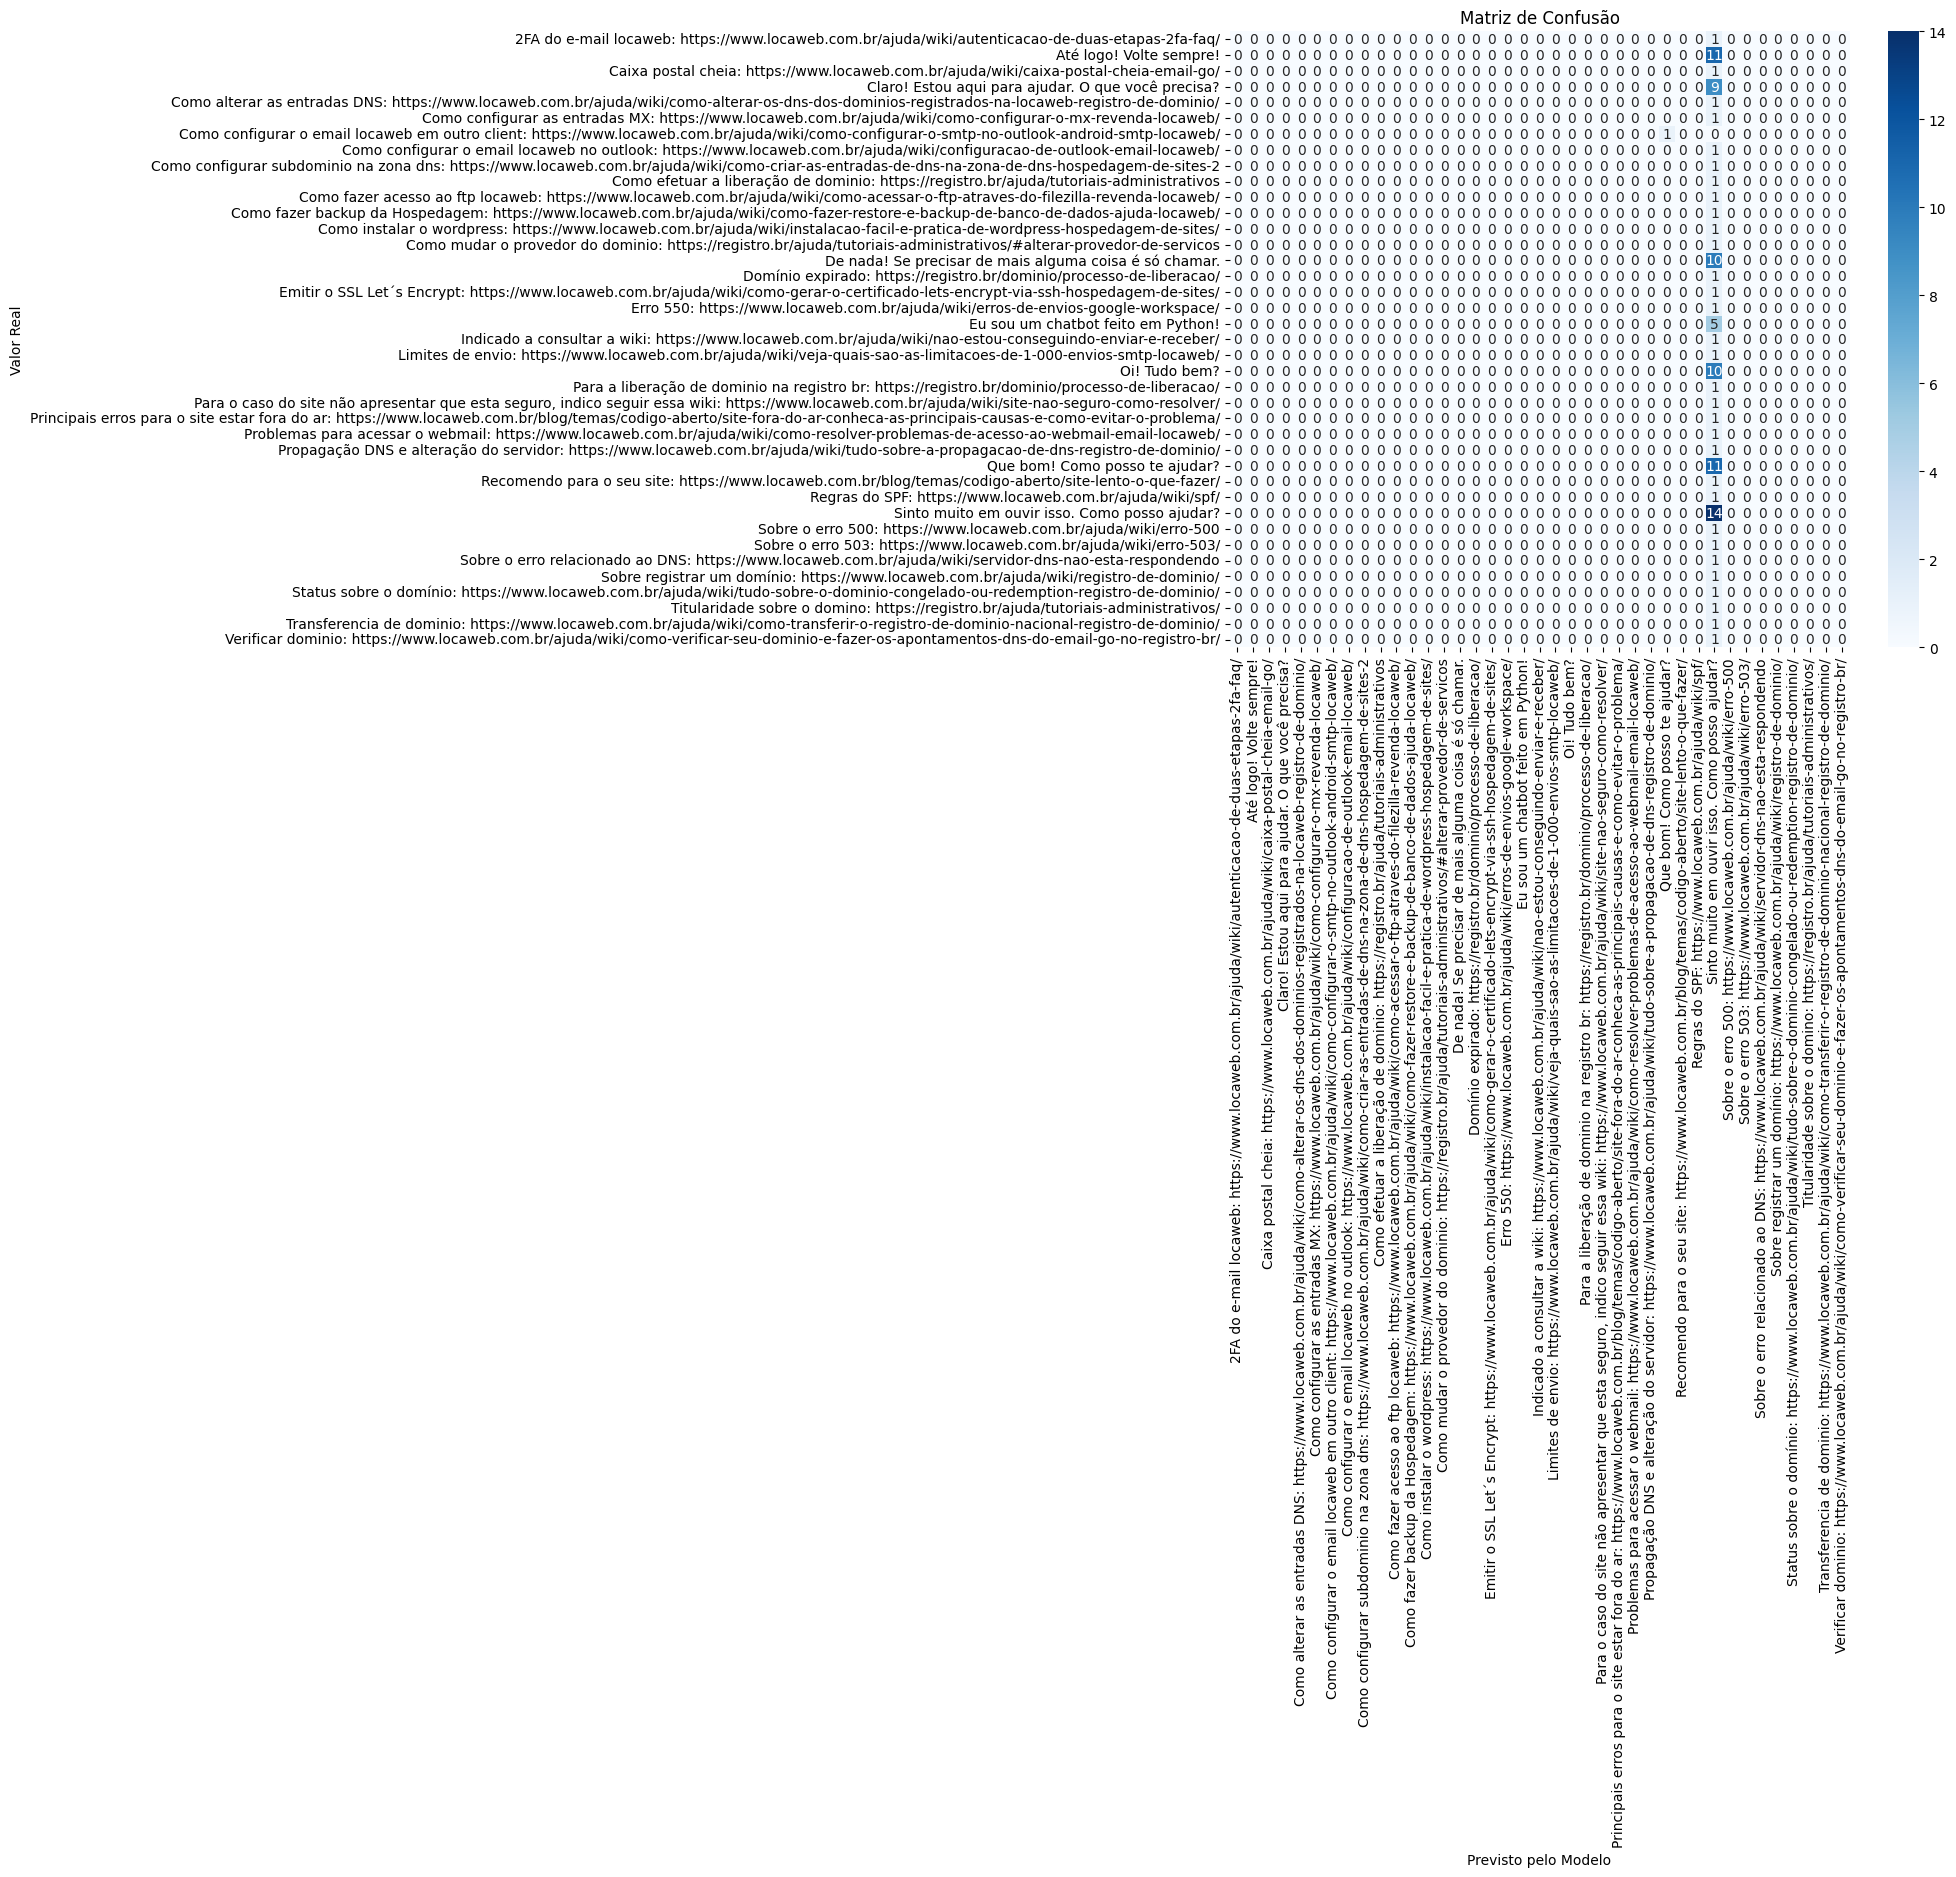

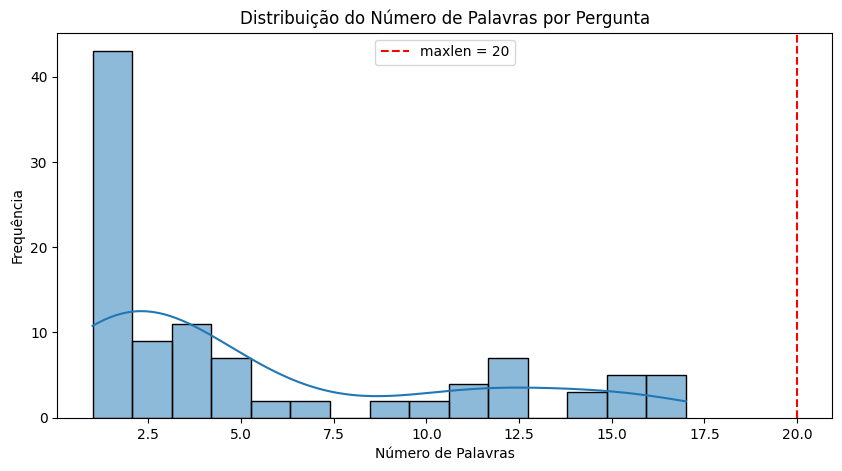

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Avaliação do modelo

#Extração do histórico de treinamento
acc = history.history['accuracy'] #acurácia de treino
val_acc = history.history['val_accuracy'] #acurácia de validação
loss = history.history['loss'] #perda de treino
val_loss = history.history['val_loss'] #perda de validação
epochs = range(1, len(acc) + 1) #número de épocas treinadas

plt.figure(figsize=(16, 6))

#Acurácia
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, label='Acurácia (Treino)')
plt.plot(epochs, val_acc, label='Acurácia (Validação)')
plt.legend(loc='upper left')
plt.title('Acurácia de Treinamento vs. Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')

#Perda 
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, label='Perda (Treino)')
plt.plot(epochs, val_loss, label='Perda (Validação)')
plt.legend(loc='upper left')
plt.title('Perda de Treinamento vs. Validação')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.show()

#Balanceamento de Classes
plt.figure(figsize=(10, 8))
sns.countplot(y=respostas)
plt.title('Distribuição de Classes nas Respostas')
plt.xlabel('Contagem')
plt.ylabel('Respostas')
plt.show()

#Matriz de Confusão
# 1. Obter as previsões do modelo para TODOS os dados
y_pred_prob = model.predict(x_processadas)
y_pred_classes = np.argmax(y_pred_prob, axis=1) # Pega a classe com maior probabilidade

# 'y_labels' foi o resultado do LabelEncoder na Etapa A (são os IDs reais)
y_true_classes = y_respostas 

# 2. Gerar a matriz
cm = confusion_matrix(y_true_classes, y_pred_classes)

# 3. Mapear os nomes das classes (do label_encoder)
class_names = label_encoder.classes_.astype(str).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusão')
plt.xlabel('Previsto pelo Modelo')
plt.ylabel('Valor Real')
plt.show()

#Distribuição do Comprimento das Frases
# Calcular o número de palavras em cada pergunta
df['comprimento_pergunta'] = df['perguntas'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data= df, x='comprimento_pergunta', bins=15, kde=True)
plt.title('Distribuição do Número de Palavras por Pergunta')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
# Linha vertical para mostrar nosso 'maxlen'
plt.axvline(x=20, color='red', linestyle='--', label=f'maxlen = {20}')
plt.legend()
plt.show()